In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pynq import Overlay, allocate

W, H, THRESHOLD = 640, 480, 100

In [2]:
def sobel_init():
    overlay = Overlay("sobel.bit")
    dma = overlay.axi_dma_0
    
    img_width_ch  = overlay.axi_gpio_0.channel1   # -> sobel_core_0.img_width
    img_height_ch = overlay.axi_gpio_0.channel2   # -> sobel_core_0.img_height
    threshold_ch  = overlay.axi_gpio_1.channel1   # -> sobel_core_0.threshold
    pixcount_ch   = overlay.axi_gpio_1.channel2   # -> sobel_core_0.frame_pixel_count
    
    img_width_ch.write(W, 0xffffffff)
    img_height_ch.write(H, 0xffffffff)
    threshold_ch.write(THRESHOLD, 0xffffffff)
    pixcount_ch.write(W * H, 0xffffffff)
    
    print("img_width  register:", img_width_ch.read(), "(expected", W, ")")
    print("img_height register:", img_height_ch.read(), "(expected", H, ")")
    print("threshold  register:", threshold_ch.read(), "(expected", THRESHOLD, ")")
    print("pixcount   register:", pixcount_ch.read(), "(expected", W * H, ")")
    
    return dma  # Return the DMA handle to use in your main script

In [3]:
def wait_for_dma(channel, name, timeout=5.0):
    start = time.time()
    while not channel.idle:
        if time.time() - start > timeout:
            raise TimeoutError(f"{name} did not go idle within {timeout}s")
        time.sleep(0.001)
    return time.time() - start

In [4]:
def edge_detection(IMAGE_PATH, dma):  
    assert os.path.exists(IMAGE_PATH), f"Image not found: {IMAGE_PATH}"
    img = Image.open(IMAGE_PATH).convert("L")
    print("Original size (W,H):", img.size)
    
    img_resized = img.resize((W, H))
    img_arr = np.array(img_resized, dtype=np.uint8)
    print("Array shape (H,W):", img_arr.shape)   # Output: (480, 640)
    assert img_arr.shape == (H, W), "Resize didn't produce the expected shape"
    
    in_buffer  = allocate(shape=(H, W), dtype=np.uint8)
    out_buffer = allocate(shape=(H, W), dtype=np.uint8)
    np.copyto(in_buffer, img_arr)
    
    print("Starting DMA transfer...")
    # DMA setup logic is correct: receive channel must be primed before sending
    dma.recvchannel.transfer(out_buffer)
    dma.sendchannel.transfer(in_buffer)

    try:
        t_send = wait_for_dma(dma.sendchannel, "MM2S (send)")
        t_recv = wait_for_dma(dma.recvchannel, "S2MM (recv)")
        print(f"Transfer complete! send={t_send*1000:.2f}ms  recv={t_recv*1000:.2f}ms")
    except TimeoutError as e:
        print("TIMED OUT:", e)
        print("MM2S status:", hex(dma.mmio.read(0x04)))
        print("S2MM status:", hex(dma.mmio.read(0x34)))
        raise

    # Display results
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    ax[0].imshow(in_buffer, cmap='gray')
    ax[0].set_title('Original Image (Grayscale)')
    ax[0].axis('off')
    ax[1].imshow(out_buffer, cmap='gray')
    ax[1].set_title(f'Hardware Sobel Output (Threshold: {THRESHOLD})')
    ax[1].axis('off')
    plt.show()
    
    # close
    in_buffer.close()
    out_buffer.close()

In [5]:
dma_handle = sobel_init()

img_width  register: 640 (expected 640 )
img_height register: 480 (expected 480 )
threshold  register: 100 (expected 100 )
pixcount   register: 307200 (expected 307200 )


Original size (W,H): (447, 447)
Array shape (H,W): (480, 640)
Starting DMA transfer...
Transfer complete! send=10.30ms  recv=0.03ms


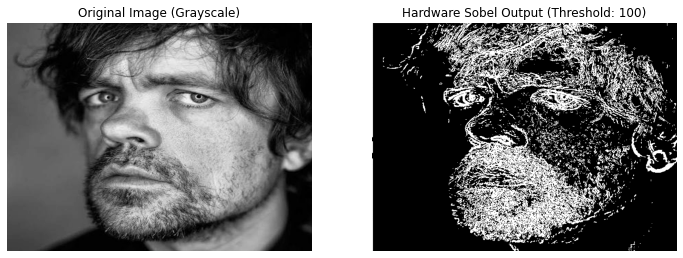

In [7]:
edge_detection("images.jpg", dma_handle)

Original size (W,H): (671, 666)
Array shape (H,W): (480, 640)
Starting DMA transfer...
Transfer complete! send=10.33ms  recv=0.03ms


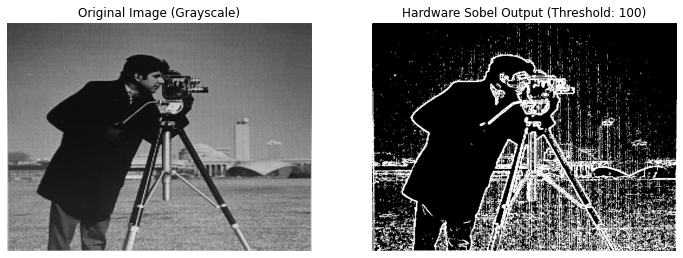

In [8]:
edge_detection("image.jpg", dma_handle)